# Customer Journey Analysis

### Complete pipeline: data prep → funnel → session → behavior → segmentation → visuals → insights

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter

In [4]:
# Load dataset
df = pd.read_csv("../data/customer_journey.csv")
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")

Loaded 12,719 rows × 10 columns


In [5]:
# Data Inspection
print("── First 5 rows ──")
print(df.head())
print("\n── Data Info ──")
print(df.info())
print("\n── Missing Values ──")
print(df.isnull().sum())

── First 5 rows ──
   SessionID     UserID            Timestamp      PageType DeviceType  \
0  session_0  user_2223  2025-01-20 22:53:34          home    Desktop   
1  session_1  user_2192  2025-02-26 12:57:10          home     Tablet   
2  session_1  user_2192  2025-02-26 12:59:11  product_page     Tablet   
3  session_2  user_1708  2025-06-24 15:40:46          home     Mobile   
4  session_3  user_2976  2025-06-11 07:21:02          home     Tablet   

   Country ReferralSource  TimeOnPage_seconds  ItemsInCart  Purchased  
0    India   Social Media                  55            0          0  
1  Germany          Email                  99            0          0  
2  Germany          Email                 121            0          0  
3    India         Google                 160            0          0  
4       UK         Google                 113            0          0  

── Data Info ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12719 entries, 0 to 12718
Data columns (tot

In [6]:
# Convert timestamps and sort 
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df.sort_values(by=["UserID", "Timestamp"], inplace=True)
df.reset_index(drop=True, inplace=True)
print("Timestamps converted & sorted by UserID + time")

Timestamps converted & sorted by UserID + time


In [7]:
# Standardise event names
# Map PageType to clean funnel stage names
stage_map = {
    "home":         "1_Visit",
    "product_page": "2_Product_View",
    "cart":         "3_Cart",
    "checkout":     "4_Checkout",
    "confirmation": "5_Purchase",
}
df["FunnelStage"] = df["PageType"].map(stage_map)
print("Funnel stages mapped:")
print(df["FunnelStage"].value_counts().sort_index())

Funnel stages mapped:
FunnelStage
1_Visit           5000
2_Product_View    3987
3_Cart            1599
4_Checkout        1123
5_Purchase        1010
Name: count, dtype: int64


## Funnel Analysis

In [8]:
# Define funnel stages & count unique users at each
funnel_order = ["1_Visit", "2_Product_View", "3_Cart", "4_Checkout", "5_Purchase"]
funnel_labels = ["Visit", "Product View", "Cart", "Checkout", "Purchase"]
 
funnel_users = {}
for stage in funnel_order:
    funnel_users[stage] = df[df["FunnelStage"] == stage]["UserID"].nunique()
 
funnel_df = pd.DataFrame({
    "Stage": funnel_labels,
    "Users": [funnel_users[s] for s in funnel_order],
})
funnel_df["Pct_of_Total"] = (funnel_df["Users"] / funnel_df["Users"].iloc[0] * 100).round(1)
funnel_df["Stage_Conversion"] = (
    funnel_df["Users"] / funnel_df["Users"].shift(1) * 100
).round(1)
funnel_df["Drop_Off_Pct"] = (100 - funnel_df["Stage_Conversion"]).round(1)
 
print("── Funnel Summary ──")
print(funnel_df.to_string(index=False))
 
# Biggest drop-off
biggest_drop_idx = funnel_df["Drop_Off_Pct"].iloc[1:].idxmax()  # skip first NaN
print(f"\nBiggest drop-off: {funnel_df.loc[biggest_drop_idx, 'Stage']} "
      f"({funnel_df.loc[biggest_drop_idx, 'Drop_Off_Pct']}% lost from prior stage)")

── Funnel Summary ──
       Stage  Users  Pct_of_Total  Stage_Conversion  Drop_Off_Pct
       Visit   1872         100.0               NaN           NaN
Product View   1763          94.2              94.2           5.8
        Cart   1084          57.9              61.5          38.5
    Checkout    855          45.7              78.9          21.1
    Purchase    792          42.3              92.6           7.4

Biggest drop-off: Cart (38.5% lost from prior stage)


## Session Analysis

In [11]:
# Session-level metrics
session_stats = df.groupby("SessionID").agg(
    UserID=("UserID", "first"),
    start_time=("Timestamp", "min"),
    end_time=("Timestamp", "max"),
    event_count=("PageType", "count"),
    purchased=("Purchased", "max"),
    device=("DeviceType", "first"),
    country=("Country", "first"),
    referral=("ReferralSource", "first"),
    total_time_on_pages=("TimeOnPage_seconds", "sum"),
).reset_index()
 
session_stats["session_duration_sec"] = (
    session_stats["end_time"] - session_stats["start_time"]
).dt.total_seconds()
session_stats["session_duration_min"] = (session_stats["session_duration_sec"] / 60).round(2)
 
print("Session Stats (first 5)")
print(session_stats.head())

# Converters vs Non-Converters
converter_stats = session_stats.groupby("purchased").agg(
    sessions=("SessionID", "count"),
    avg_duration_min=("session_duration_min", "mean"),
    avg_events=("event_count", "mean"),
    avg_time_on_pages=("total_time_on_pages", "mean"),
).round(2)
converter_stats.index = converter_stats.index.map({0: "Non-Converter", 1: "Converter"})
 
print("\nConverters vs Non-Converters")
print(converter_stats)

Session Stats (first 5)
      SessionID     UserID          start_time            end_time  \
0     session_0  user_2223 2025-01-20 22:53:34 2025-01-20 22:53:34   
1     session_1  user_2192 2025-02-26 12:57:10 2025-02-26 12:59:11   
2    session_10  user_2357 2025-05-17 22:11:37 2025-05-17 22:13:33   
3   session_100  user_1233 2025-04-02 11:24:36 2025-04-02 11:25:41   
4  session_1000  user_1551 2025-08-25 09:34:15 2025-08-25 09:41:24   

   event_count  purchased   device  country      referral  \
0            1          0  Desktop    India  Social Media   
1            2          0   Tablet  Germany         Email   
2            2          0   Tablet    India        Direct   
3            2          0  Desktop      USA         Email   
4            5          1   Mobile   France         Email   

   total_time_on_pages  session_duration_sec  session_duration_min  
0                   55                   0.0                  0.00  
1                  220                 121.0      

## User Behaviour

In [13]:
# Build user journey paths
journey_paths = (
    df.sort_values(["SessionID", "Timestamp"])
    .groupby("SessionID")["PageType"]
    .apply(lambda x: " → ".join(x))
    .reset_index()
    .rename(columns={"PageType": "journey_path"})
)
 
# Merge purchase flag
journey_paths = journey_paths.merge(
    session_stats[["SessionID", "purchased"]], on="SessionID"
)
 
print(f"Total unique paths: {journey_paths['journey_path'].nunique()}")
print("\nTotal Unique Paths")
path_counts = journey_paths["journey_path"].value_counts().head(10)
for path, cnt in path_counts.items():
    print(f"  {cnt:>5}× | {path}")

Total unique paths: 5

Total Unique Paths
   2388× | home → product_page
   1013× | home
   1010× | home → product_page → cart → checkout → confirmation
    476× | home → product_page → cart
    113× | home → product_page → cart → checkout


In [16]:
# Common paths to PURCHASE
purchase_paths = (
    journey_paths[journey_paths["purchased"] == 1]["journey_path"]
    .value_counts()
    .head(10)
)
print("\nTop 10 Paths That Led to Purchase")
for path, cnt in purchase_paths.items():
    print(f"{cnt:>5}× | {path}")


Top 10 Paths That Led to Purchase
 1010× | home → product_page → cart → checkout → confirmation


In [18]:
# Time to conversion (first visit → first purchase per user)
user_first_visit = (
    df[df["FunnelStage"] == "1_Visit"]
    .groupby("UserID")["Timestamp"]
    .min()
    .rename("first_visit")
)
user_first_purchase = (
    df[df["FunnelStage"] == "5_Purchase"]
    .groupby("UserID")["Timestamp"]
    .min()
    .rename("first_purchase")
)
time_to_convert = pd.concat([user_first_visit, user_first_purchase], axis=1).dropna()
time_to_convert["days_to_convert"] = (
    time_to_convert["first_purchase"] - time_to_convert["first_visit"]
).dt.total_seconds() / 86400
 
print("\nTime to Conversion (days)")
print(time_to_convert["days_to_convert"].describe().round(2))


Time to Conversion (days)
count    792.00
mean      47.19
std       60.45
min        0.00
25%        0.00
50%       13.16
75%       84.83
max      233.29
Name: days_to_convert, dtype: float64


## Segmentation

In [20]:
# Create user segments
user_summary = df.groupby("UserID").agg(
    total_sessions=("SessionID", "nunique"),
    ever_purchased=("Purchased", "max"),
    ever_carted=("FunnelStage", lambda x: int(("3_Cart" in x.values))),
    pages_visited=("PageType", "count"),
    avg_time_per_page=("TimeOnPage_seconds", "mean"),
    devices_used=("DeviceType", "nunique"),
    primary_device=("DeviceType", lambda x: x.mode().iloc[0]),
    primary_referral=("ReferralSource", lambda x: x.mode().iloc[0]),
    primary_country=("Country", lambda x: x.mode().iloc[0]),
).reset_index()
 
def assign_segment(row):
    if row["ever_purchased"] == 1:
        return "Buyer"
    elif row["ever_carted"] == 1:
        return "Cart Abandoner"
    else:
        return "Browser"
 
user_summary["segment"] = user_summary.apply(assign_segment, axis=1)
 
segment_counts = user_summary["segment"].value_counts()
print("User Segments")
print(segment_counts)
print(f"\nTotal users: {len(user_summary):,}")

User Segments
segment
Buyer             792
Browser           788
Cart Abandoner    292
Name: count, dtype: int64

Total users: 1,872


In [21]:
# Compare behaviour across segments
segment_behavior = user_summary.groupby("segment").agg(
    user_count=("UserID", "count"),
    avg_sessions=("total_sessions", "mean"),
    avg_pages=("pages_visited", "mean"),
    avg_time_per_page=("avg_time_per_page", "mean"),
).round(2)
 
print("\nSegment Behavior Comparison")
print(segment_behavior)


Segment Behavior Comparison
                user_count  avg_sessions  avg_pages  avg_time_per_page
segment                                                               
Browser                788          2.04       3.48              97.87
Buyer                  792          3.26      10.23              97.59
Cart Abandoner         292          2.77       6.41              96.85


## Visualisations

In [22]:
sns.set_theme(style="whitegrid", font_scale=1.1)
palette = ["#3a86ff", "#2ec4b6", "#ffbe0b", "#fb5607", "#ff006e"]

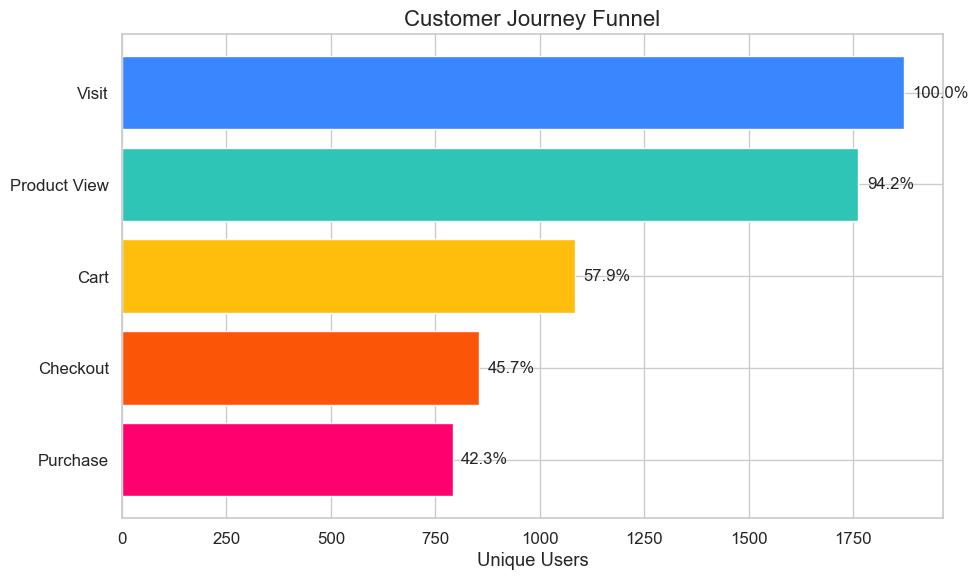

Saved outputs/01_funnel_chart.png


In [31]:
# 1. Funnel Chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(funnel_df["Stage"][::-1], funnel_df["Users"][::-1], color=palette[::-1])
for bar, pct in zip(bars, funnel_df["Pct_of_Total"][::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f"{pct}%", va="center", fontsize=12)
ax.set_xlabel("Unique Users")
ax.set_title("Customer Journey Funnel", fontsize=16)
plt.tight_layout()
plt.savefig("../outputs/01_funnel_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved outputs/01_funnel_chart.png")

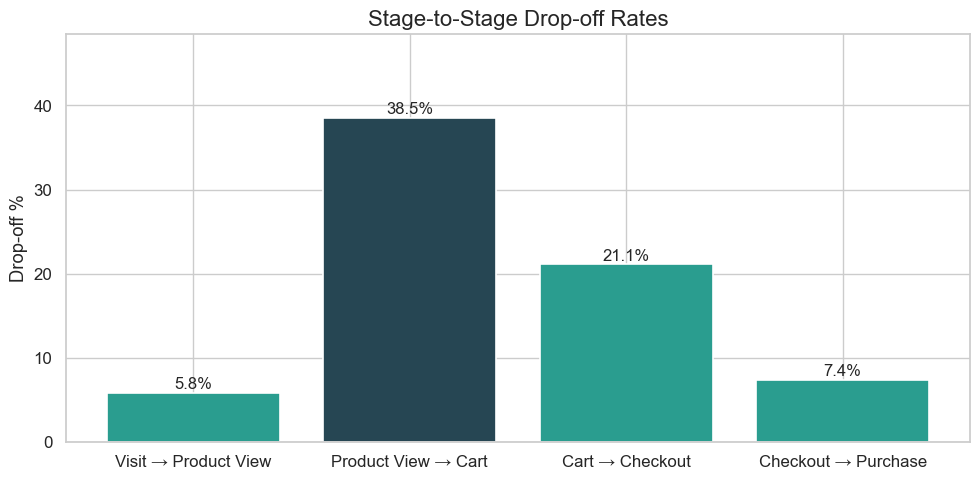

Saved outputs/02_dropoff_chart.png


In [38]:
# 2. Stage-to-Stage Drop-off Chart
fig, ax = plt.subplots(figsize=(10, 5))
stages_pair = [f"{funnel_labels[i]} → {funnel_labels[i+1]}" for i in range(len(funnel_labels)-1)]
drop_vals = funnel_df["Drop_Off_Pct"].iloc[1:].values
colors = ["#264653" if v == max(drop_vals) else "#2a9d8f" for v in drop_vals]
bars = ax.bar(stages_pair, drop_vals, color=colors, edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, drop_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val}%", ha="center", fontsize=12)
ax.set_ylabel("Drop-off %")
ax.set_title("Stage-to-Stage Drop-off Rates", fontsize=16)
ax.set_ylim(0, max(drop_vals) + 10)
plt.tight_layout()
plt.savefig("../outputs/02_dropoff_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved outputs/02_dropoff_chart.png")

/var/folders/fx/6drlnz3j6433wqgbqhv43bhm0000gn/T/ipykernel_13816/3114177679.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=session_stats, x="label", y="session_duration_min",
/var/folders/fx/6drlnz3j6433wqgbqhv43bhm0000gn/T/ipykernel_13816/3114177679.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=session_stats, x="label", y="event_count",
/var/folders/fx/6drlnz3j6433wqgbqhv43bhm0000gn/T/ipykernel_13816/3114177679.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=session_stats, x="label", y="total_time_on_pages",


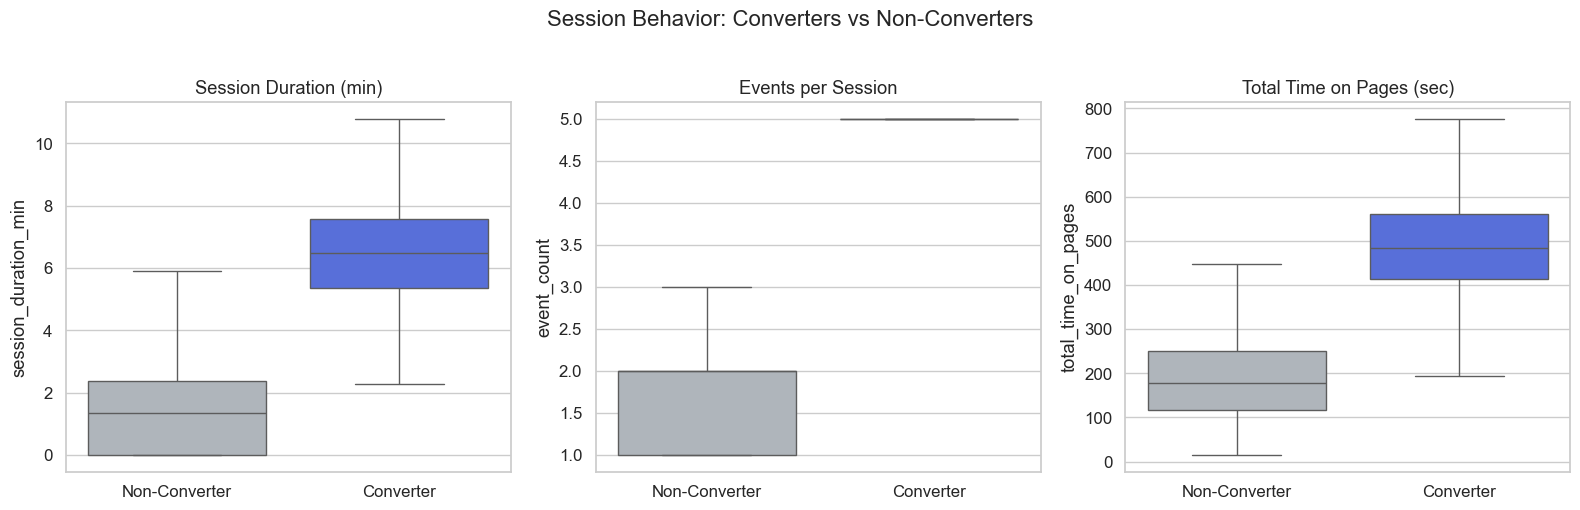

Saved outputs/03_session_behavior.png


In [32]:
# 3. Session Behaviour: Converters vs Non-Converters
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
# 3a - Session duration
session_stats["label"] = session_stats["purchased"].map({0: "Non-Converter", 1: "Converter"})
sns.boxplot(data=session_stats, x="label", y="session_duration_min",
            palette=["#adb5bd", "#4361ee"], ax=axes[0], showfliers=False)
axes[0].set_title("Session Duration (min)")
axes[0].set_xlabel("")
 
# 3b - Events per session
sns.boxplot(data=session_stats, x="label", y="event_count",
            palette=["#adb5bd", "#4361ee"], ax=axes[1], showfliers=False)
axes[1].set_title("Events per Session")
axes[1].set_xlabel("")
 
# 3c - Time on pages
sns.boxplot(data=session_stats, x="label", y="total_time_on_pages",
            palette=["#adb5bd", "#4361ee"], ax=axes[2], showfliers=False)
axes[2].set_title("Total Time on Pages (sec)")
axes[2].set_xlabel("")
 
plt.suptitle("Session Behavior: Converters vs Non-Converters",
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/03_session_behavior.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved outputs/03_session_behavior.png")

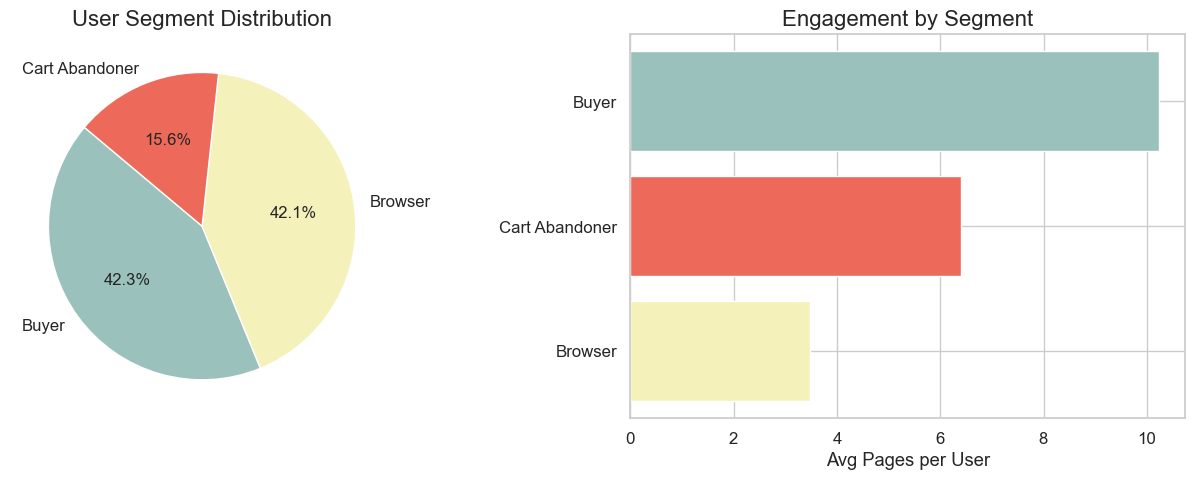

Saved outputs/04_segment_distribution.png


In [35]:
# 4. Segment Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Pie
seg_colors = {"Buyer": "#9bc1bc", "Cart Abandoner": "#ed6a5a", "Browser": "#f4f1bb"}
axes[0].pie(segment_counts.values, labels=segment_counts.index, autopct="%1.1f%%",
            colors=[seg_colors[s] for s in segment_counts.index],
            startangle=140, textprops={"fontsize": 12})
axes[0].set_title("User Segment Distribution", fontsize=16)
 
# Bar - avg pages by segment
segment_behavior_sorted = segment_behavior.sort_values("avg_pages", ascending=True)
axes[1].barh(segment_behavior_sorted.index, segment_behavior_sorted["avg_pages"],
             color=[seg_colors[s] for s in segment_behavior_sorted.index])
axes[1].set_xlabel("Avg Pages per User")
axes[1].set_title("Engagement by Segment", fontsize=16)
 
plt.tight_layout()
plt.savefig("../outputs/04_segment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved outputs/04_segment_distribution.png")

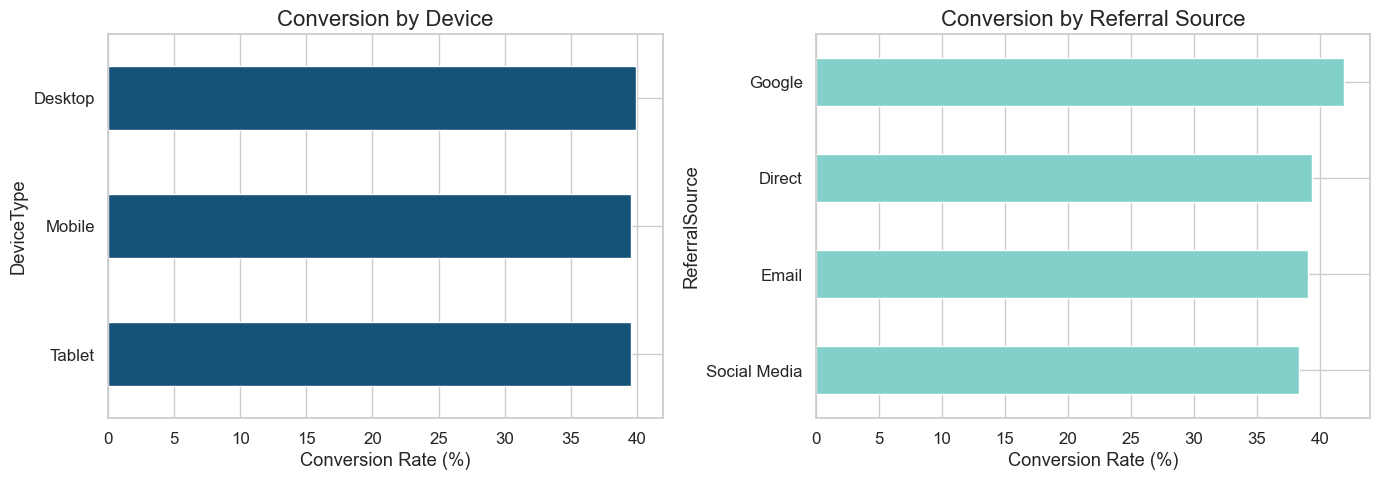

Saved outputs/05_conversion_by_device_referral.png


In [36]:
# 5. Conversion by Device & Referral
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# By device
device_conv = df.groupby("DeviceType")["Purchased"].mean() * 100
device_conv.sort_values().plot.barh(ax=axes[0], color="#145277")
axes[0].set_xlabel("Conversion Rate (%)")
axes[0].set_title("Conversion by Device", fontsize=16)
 
# By referral
ref_conv = df.groupby("ReferralSource")["Purchased"].mean() * 100
ref_conv.sort_values().plot.barh(ax=axes[1], color="#83d0cb")
axes[1].set_xlabel("Conversion Rate (%)")
axes[1].set_title("Conversion by Referral Source", fontsize=16)
 
plt.tight_layout()
plt.savefig("../outputs/05_conversion_by_device_referral.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved outputs/05_conversion_by_device_referral.png")

## Insights & Recommendations

In [41]:
print("💡 KEY INSIGHTS & BUSINESS RECOMMENDATIONS")
 
# Bottleneck
print(f"""
🔴 BOTTLENECK ANALYSIS
   • Biggest drop-off: {funnel_df.loc[biggest_drop_idx, 'Stage']} stage
     ({funnel_df.loc[biggest_drop_idx, 'Drop_Off_Pct']}% of users lost)
   • Only {funnel_df['Pct_of_Total'].iloc[-1]}% of visitors complete a purchase
""")
 
# Converter behavior
conv_row = converter_stats.loc["Converter"]
nonconv_row = converter_stats.loc["Non-Converter"]
print(f"""🟢 HIGH-CONVERTING BEHAVIORS
   • Converters average {conv_row['avg_events']:.1f} events/session vs {nonconv_row['avg_events']:.1f} for non-converters
   • Converters spend {conv_row['avg_duration_min']:.1f} min/session vs {nonconv_row['avg_duration_min']:.1f} min for non-converters
   • Top purchase path: {purchase_paths.index[0]}
""")
 
# Segments
buyer_pct = (segment_counts.get("Buyer", 0) / segment_counts.sum() * 100).round(1)
abandon_pct = (segment_counts.get("Cart Abandoner", 0) / segment_counts.sum() * 100).round(1)
print(f"""👥 SEGMENTATION INSIGHTS
   • Buyers:          {segment_counts.get('Buyer', 0):,} users ({buyer_pct}%)
   • Cart Abandoners: {segment_counts.get('Cart Abandoner', 0):,} users ({abandon_pct}%)
   • Browsers:        {segment_counts.get('Browser', 0):,} users
""")
 
# Recommendations
print("""📋 RECOMMENDATIONS
   1. Reduce the biggest funnel drop-off with targeted UX improvements and clearer CTAs at that stage.
   2. Launch cart-abandonment email campaigns — a significant share of users add items but never check out.
   3. Optimise for the top converting journey path by streamlining navigation along that flow.
   4. Invest in the highest-converting referral channel and test similar messaging on underperforming ones.
   5. Personalise the experience for "Browser" users — product recommendations or exit-intent offers to move them deeper into the funnel.
""")

💡 KEY INSIGHTS & BUSINESS RECOMMENDATIONS

🔴 BOTTLENECK ANALYSIS
   • Biggest drop-off: Cart stage
     (38.5% of users lost)
   • Only 42.3% of visitors complete a purchase

🟢 HIGH-CONVERTING BEHAVIORS
   • Converters average 5.0 events/session vs 1.9 for non-converters
   • Converters spend 6.5 min/session vs 1.5 min for non-converters
   • Top purchase path: home → product_page → cart → checkout → confirmation

👥 SEGMENTATION INSIGHTS
   • Buyers:          792 users (42.3%)
   • Cart Abandoners: 292 users (15.6%)
   • Browsers:        788 users

📋 RECOMMENDATIONS
   1. Reduce the biggest funnel drop-off with targeted UX improvements and clearer CTAs at that stage.
   2. Launch cart-abandonment email campaigns — a significant share of users add items but never check out.
   3. Optimise for the top converting journey path by streamlining navigation along that flow.
   4. Invest in the highest-converting referral channel and test similar messaging on underperforming ones.
   5. Persona